In [1]:
#import bert_score
#from deepeval.metrics import GEval
#from deepeval.test_case import LLMTestCase, LLMTestCaseParams
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import pprint
from sklearn import metrics
import urllib

#from deepeval.models import AmazonBedrockModel

#import boto3
from pydantic_ai.models.bedrock import BedrockConverseModel
from pydantic_evals import Dataset, Case
from pydantic_evals.evaluators import LLMJudge
from pydantic_ai.settings import ModelSettings

import asyncio
import concurrent.futures

#from ragas.metrics import AnswerCorrectness 
#from ragas import EvaluationDataset, evaluate as ragas_evaluate
#from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
#from ragas.llms import LangchainLLMWrapper
#from ragas.embeddings import LangchainEmbeddingsWrapper

import nest_asyncio
nest_asyncio.apply()

In [2]:
normalise_threshold=True

In [3]:
settings={}
settings["n_prompts"] = 30
settings["region"] = "eu-west-2"
settings["temperature"] = 0
settings["threshold"] = 0.5

In [4]:
models = {}

#models['Claude 3 Haiku'] = 'anthropic.claude-3-haiku-20240307-v1:0'
models['Claude 3.7 Sonnet'] = 'anthropic.claude-3-7-sonnet-20250219-v1:0'
#models['GPT OSS 20b'] = "openai.gpt-oss-20b-1:0"
models['GPT OSS 120b'] = "openai.gpt-oss-120b-1:0"

## Set Environment Variables

In [5]:
os.environ["AWS_DEFAULT_REGION"] = settings["region"]

## Get Data

In [6]:
datasets = [
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/dialogue_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/general_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/qa_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/summarization_data.json'
   ]

In [7]:
for directory in ['data', 'output']:
    if not os.path.exists(directory):
        os.makedirs(directory)
    
for dataset in datasets:
    print(dataset)
    filename=dataset.split('/')[-1]
    if not os.path.isfile(f'data/{filename}'):
        print(f'downloading {filename}')
        urllib.request.urlretrieve(dataset, f'data/{filename}')

https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/dialogue_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/general_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/qa_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/summarization_data.json


## Summarisation

In [8]:
rubric = """
You are a summary judge. You MUST determine if the provided summary contains non-factual or hallucinated information. The answer you give MUST be \"Yes\" or \"No\"
"""

summarisation_df = pd.read_json("data/summarization_data.json", lines=True)
summarisation_df

summarisation_not_hallucination_df = summarisation_df.copy()
summarisation_not_hallucination_df['summary'] = summarisation_not_hallucination_df['right_summary']
summarisation_not_hallucination_df['is_hallucination'] = False

summarisation_hallucination_df = summarisation_df.copy()
summarisation_hallucination_df['summary'] = summarisation_hallucination_df['hallucinated_summary']
summarisation_hallucination_df['is_hallucination'] = True

summarisation_answers_df = pd.concat([summarisation_not_hallucination_df, summarisation_hallucination_df])
summarisation_answers_df.reset_index(drop=True)
summarisation_answers_df

,document,right_summary,hallucinated_summary,summary,is_hallucination
0,"Marseille, France (CNN)The French prosecutor l...","Marseille prosecutor says ""so far no videos we...",A video showing the final moments of Germanwin...,"Marseille prosecutor says ""so far no videos we...",False
1,The Palestinian Authority officially became th...,Membership gives the ICC jurisdiction over all...,The International Criminal Court has officiall...,Membership gives the ICC jurisdiction over all...,False
2,Governments around the world are using the thr...,Amnesty's annual death penalty report catalogs...,Amnesty's annual report on the death penalty s...,Amnesty's annual death penalty report catalogs...,False
3,"On May 28, 2014, some 7,000 people gathered in...",Amnesty International releases its annual revi...,China paraded scores of prisoners at a mass se...,Amnesty International releases its annual revi...,False
4,"Seventy years ago, Anne Frank died of typhus i...",Museum: Anne Frank died earlier than previousl...,Anne Frank and her sister Margot were found al...,Museum: Anne Frank died earlier than previousl...,False
...,...,...,...,...,...
9995,Fired: Major General James Post III was fired ...,Major General James Post III was fired for say...,An Air Force major general was removed from hi...,An Air Force major general was removed from hi...,True
9996,"American Apparel, the controversial retailer k...",The print ad ran in the most recent issue of V...,American Apparel has launched a successful 'pr...,American Apparel has launched a successful 'pr...,True
9997,Angelina Jolie may have made the character wor...,Bonnie's skill at playing Call Of Duty has gai...,"Bonnie Doll, the real-life Lara Croft of Austr...","Bonnie Doll, the real-life Lara Croft of Austr...",True
9998,The disabled pensioner who received donations ...,"Alan Barnes, who is partially sighted and just...","Alan Barnes, a drug addict who was jailed for ...","Alan Barnes, a drug addict who was jailed for ...",True


In [9]:
def evaluate_pydantic(document: str, summary: str, settings: dict) -> dict:

    rubric = settings["rubric"]

    judge = LLMJudge(
        model=BedrockConverseModel(settings["model_id"]),
        rubric=rubric,
        score={'evaluation_name': 'HallucinationScore'},
        model_settings=ModelSettings(
            temperature=settings["temperature"],
            max_tokens=2048,
        ),
        include_input=True,
        include_expected_output=True,
    )

    dataset = Dataset(
        cases=[Case(inputs=document)],
        evaluators=[judge],
    )

    def run_in_thread():
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        try:
            return loop.run_until_complete(dataset.evaluate(lambda x: summary))
        finally:
            loop.close()

    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as executor:
        report = executor.submit(run_in_thread).result()

    case_result = report.cases[0]
    score = 1 - case_result.scores['HallucinationScore'].value

    return {
        'method': 'Pydantic',
        'score': score,       # 0 = clean, 1 = fully hallucinated
        'reason': case_result.assertions['LLMJudge_pass'].reason,
        'passed': score >= settings['threshold']
    }

settings["rubric"] = """
    Your task is to detect hallucinations in a summary.
    
    DEFINITIONS:
    - HALLUCINATION: Any claim in the summary that is fabricated, exaggerated, contradicts, 
      or cannot be verified from the source document.
    - NOT A HALLUCINATION: Every claim in the summary can be directly verified or reasonably 
      inferred from the source document.
    
    SOURCE DOCUMENT:
    {input}
    
    SUMMARY TO EVALUATE:
    {output}
    
    INSTRUCTIONS:
    1. Read every factual claim in the SUMMARY.
    2. For each claim, check if it is supported by the SOURCE DOCUMENT.
    3. If ANY claim is unsupported or contradicted, the summary contains hallucinations.
    
    YOU MUST RESPOND WITH ONLY:
    - Score 0.0 if the summary contains ANY hallucinated content
    - Score 1.0 if every claim in the summary is fully supported by the source document
    
    Do not award partial scores. Be strict: if a claim cannot be verified, it is a hallucination.
    Provide a detailed explanation listing each hallucinated claim found.
"""

In [10]:
settings["rubric"] = """
    You are evaluating whether a summary (input) contains hallucinated content — 
    information that is fabricated, distorted, or not supported by the source document (expected_output).

    KNOWLEDGE BASE:
    {input}

    DIALOGUE HISTORY (context only, not ground truth):
    {expected_output}

    RESPONSE TO EVALUATE:
    {output}

    Score the summary from 0.0 to 1.0 where:
    - 0.0 = No hallucinations. Every claim in the summary is fully supported by the source document.
    - 0.25 = Minor hallucinations. Mostly accurate with 1-2 small unsupported details.
    - 0.5 = Moderate hallucinations. Several claims are inaccurate or unsupported.
    - 0.75 = Significant hallucinations. Many claims contradict or are absent from the source.
    - 1.0 = Severe hallucinations. The summary is largely fabricated or contradicts the document.

    Evaluate each factual claim in the summary and check whether it is:
    1. Explicitly stated in the source document (supported)
    2. Reasonably inferable from the source document (acceptable)
    3. Not present in the source document (unsupported — potential hallucination)
    4. Contradicted by the source document (hallucination)

    Return a score and a detailed explanation citing specific hallucinated claims if found.
    """.strip()

In [11]:
settings["rubric"] = """
    Your task is to detect hallucinations in a summary.
    
    DEFINITIONS:
    - HALLUCINATION: Any claim in the summary that is fabricated, exaggerated, contradicts, 
      or cannot be verified from the source document.
    - NOT A HALLUCINATION: Every claim in the summary can be directly verified or reasonably 
      inferred from the source document.
    
    SOURCE DOCUMENT:
    {input}
    
    SUMMARY TO EVALUATE:
    {output}
    
    INSTRUCTIONS:
    1. Read every factual claim in the SUMMARY.
    2. For each claim, check if it is supported by the SOURCE DOCUMENT.
    3. If ANY claim is unsupported or contradicted, the summary contains hallucinations.
    
    YOU MUST RESPOND WITH ONLY:
    - Score 0.0 if the summary contains ANY hallucinated content
    - Score 1.0 if every claim in the summary is fully supported by the source document
    
    Do not award partial scores. Be strict: if a claim cannot be verified, it is a hallucination.
    Provide a detailed explanation listing each hallucinated claim found.
"""

In [12]:
sample_df = summarisation_answers_df.sample(settings["n_prompts"])
#qa_sample_df = qa_answers_df[qa_answers_df["Question"]=="What happens to you if you eat watermelon seeds?"]

evaluations = []
for model_name, model_id in models.items():
    settings["model_name"] = model_name
    settings["model_id"] = model_id

    for row in sample_df.to_dict('records'):
        try:
            evaluation = evaluate_pydantic(row["document"], row["summary"], settings)
            evaluations.append(row|settings|evaluation)
            print(f"\ndocument:{row["document"]}\n\nsummary:{row["summary"]}\n\nanswer:{row["summary"]}\nhallucination: {row["is_hallucination"]}, score: {evaluation["score"]}\n")
        except:
            print('passing')
            pass

evaluations_df = pd.DataFrame(evaluations)
evaluations_df.to_csv('output/qanda_hallucinations.csv', index=False)
evaluations_df

Output()

Output()


document:It may come as a surprise to some - particularly Arsene Wenger and Pep Guardiola - but Jose Mourinho has revealed how Sir Alex Ferguson inspired him to try to be a gracious manager. The Chelsea boss said in a wide-ranging interview with the Telegraph that the legendary Manchester United manager showed him 'two faces' during their first competitive meeting in 2004 - the first one of a steely rival and the second one of a sporting loser. Mourinho had just made his first impression on the Champions League by knocking out United with unfancied Porto. The Portuguese sprinted down the touchline at Old Trafford in an unforgettable celebration of Porto's last-gasp goal that sealed qualification and a seismic shock. Sir Alex Ferguson and Jose Mourinho formed a firm friendship despite being fierce rivals. Fergie's Manchester United were stunned by Mourinho's Porto in the Champions League in 2004. Mourinho sprinted down the touchline in celebration at Porto's last-gasp goal that sealed 

,document,right_summary,hallucinated_summary,summary,is_hallucination,n_prompts,region,temperature,threshold,rubric,model_name,model_id,method,score,reason,passed
0,It may come as a surprise to some - particular...,Jose Mourinho has spoken about his first meeti...,Jose Mourinho has revealed how Arsene Wenger i...,Jose Mourinho has spoken about his first meeti...,False,30,eu-west-2,0,0.5,\n Your task is to detect hallucinations in...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,"The summary contains hallucinations:\n\n1. ""Mo...",True
1,Three hours after giving birth to her longed-f...,Lianne Hindle suffered a cardiac arrest at Nor...,A mother-of-three was declared dead three hour...,A mother-of-three was declared dead three hour...,True,30,eu-west-2,0,0.5,\n Your task is to detect hallucinations in...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The summary contains several hallucinations:\n...,True
2,"What the hell am I doing, I ask myself, as I s...",Sarah Foot began swimming outside after a dip ...,Sarah Foot loves swimming in the Mediterranean...,Sarah Foot loves swimming in the Mediterranean...,True,30,eu-west-2,0,0.5,\n Your task is to detect hallucinations in...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The summary contains multiple hallucinations:\...,True
3,The Ministry of Defence was under fire after v...,The MoD accidentally published information on ...,The Ministry of Defence has released sensitive...,The Ministry of Defence has released sensitive...,True,30,eu-west-2,0,0.5,\n Your task is to detect hallucinations in...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,0.0,I've carefully analyzed the summary against th...,False
4,Premier League clubs are now so wealthy throug...,Drinks company offered Premier League £45milli...,Premier League clubs reject £135m offer from G...,Drinks company offered Premier League £45milli...,False,30,eu-west-2,0,0.5,\n Your task is to detect hallucinations in...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,0.0,After carefully checking each claim in the sum...,False
5,Violent spectators might not be the only ones ...,NRL head of football Todd Greenberg said the m...,NRL players have been warned to behave after a...,NRL players have been warned to behave after a...,True,30,eu-west-2,0,0.5,\n Your task is to detect hallucinations in...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The summary contains a hallucination. The clai...,True
6,PGA Tour star Rickie Fowler has earned extra b...,The PGA Tour star has earned extra brownie poi...,PGA star Rickie Fowler came to his girlfriend'...,The PGA Tour star has earned extra brownie poi...,False,30,eu-west-2,0,0.5,\n Your task is to detect hallucinations in...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,0.0,I've carefully compared each claim in the summ...,False
7,Police in Surrey are hunting two raiders who s...,The raiders stripped off before entering the E...,Two bare-chested men were caught on CCTV whils...,The raiders stripped off before entering the E...,False,30,eu-west-2,0,0.5,\n Your task is to detect hallucinations in...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,0.0,I've carefully checked each claim in the summa...,False
8,Jockey Aidan Coleman is hoping he has received...,Jockey Aidan Coleman wants to right past wrong...,"Aidan Coleman, the renowned jockey, is set to ...","Aidan Coleman, the renowned jockey, is set to ...",True,30,eu-west-2,0,0.5,\n Your task is to detect hallucinations in...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The summary contains multiple hallucinations:\...,True
9,A stern defensive line has twice helped Jose M...,Jose Mourinho has a stunning defensive record ...,Chelsea boss Jose Mourinho has set a new Premi...,Chelsea boss Jose Mourinho has set a new Premi...,True,30,e

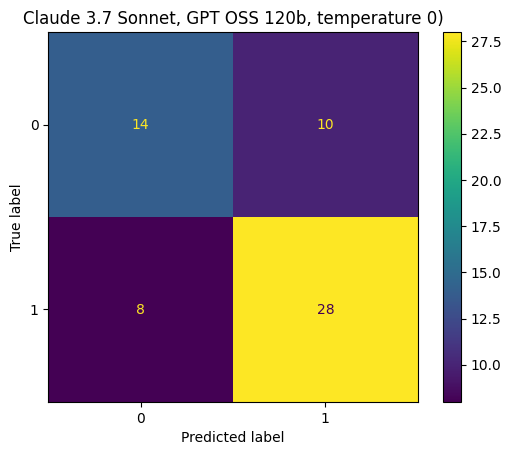

precision: 0.74, recall: 0.78, f1: 0.76

{'f1': 0.7567567567567568,
 'model_name': 'Claude 3.7 Sonnet, GPT OSS 120b',
 'precision': 0.7368421052631579,
 'recall': 0.7777777777777778,
 'score_diff': np.float64(0.3611111111111111),
 'score_hallucination': np.float64(0.7777777777777778),
 'score_mean': np.float64(0.6333333333333331),
 'score_median': np.float64(1.0),
 'score_not_hallucination': np.float64(0.4166666666666667),
 'temperature': '0'}


In [13]:
def get_results(df):
    results = {}

    results["model_name"] = f"{", ".join(df["model_name"].drop_duplicates().values)}"
    results["temperature"] = f"{str(df["temperature"].drop_duplicates().values[0])}"

    results["score_hallucination"] = df[df["is_hallucination"]]["score"].mean()
    results["score_not_hallucination"] = df[~df["is_hallucination"]]["score"].mean()
    results["score_diff"] = results["score_hallucination"] - results["score_not_hallucination"]
    results["score_mean"] = df["score_mean"].mean()
    results["score_median"] = df["score_median"].mean()
    #results["score_mean"] = (results["score_correct"] + results["score_incorrect"])/2
      
    results["precision"] = metrics.precision_score(df["is_hallucination"], df["passed"], zero_division=np.nan)
    results["recall"] = metrics.recall_score(df["is_hallucination"], df["passed"])
    results["f1"] = metrics.f1_score(df["is_hallucination"], df["passed"])
    confusion_matrix = metrics.confusion_matrix(df["is_hallucination"], df["passed"])
    
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
    cm_display.plot()
    #plt.title(f"{results["method"]} ({results["model_name"]})")
    plt.title(f"{results["model_name"]}, temperature {results["temperature"]})")
    plt.show()
    print(f"precision: {results["precision"]:.2}, recall: {results["recall"]:.2}, f1: {results["f1"]:.2}\n")
    
    return results

evaluations_df["score_mean"] = evaluations_df.groupby('model_name')['score'].transform('mean')
evaluations_df["score_median"] = evaluations_df.groupby('model_name')['score'].transform('median')

results = get_results(evaluations_df)
pprint.pprint(results)

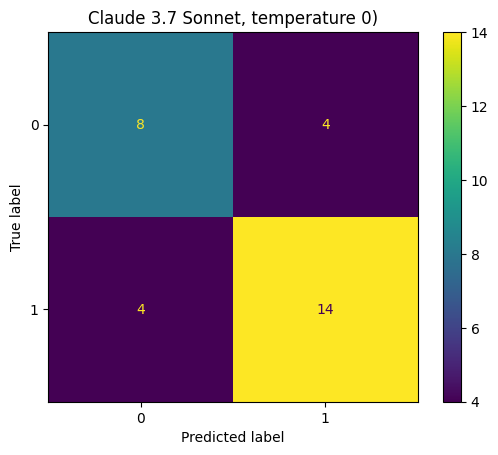

precision: 0.78, recall: 0.78, f1: 0.78



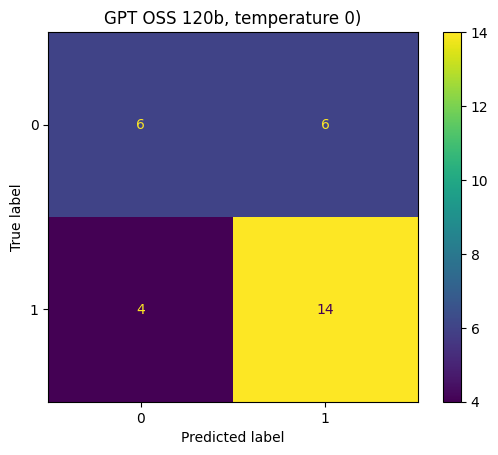

precision: 0.7, recall: 0.78, f1: 0.74



,model_name,temperature,score_hallucination,score_not_hallucination,score_diff,score_mean,score_median,precision,recall,f1
0,Claude 3.7 Sonnet,0,0.777778,0.333333,0.444444,0.600000,1.0,0.777778,0.777778,0.777778
1,GPT OSS 120b,0,0.777778,0.500000,0.277778,0.666667,1.0,0.700000,0.777778,0.736842


In [14]:
results_models = []
for row in evaluations_df[['model_name']].drop_duplicates().to_dict('records'):
    filter_df = evaluations_df.copy()
    filter_df = filter_df[filter_df['model_name'] == row['model_name']]

    if len(filter_df) > 0:
        results = get_results(filter_df)
        results_models.append(results)

results_df = pd.DataFrame(results_models)
results_df.to_csv('output/results.csv', index=False)
results_df

,temperature,score_hallucination,score_not_hallucination,score_diff,score_mean,score_median,precision,recall,f1
model_name,,,,,,,,,
Claude 3.7 Sonnet,0,0.777778,0.333333,0.444444,0.600000,1.0,0.777778,0.777778,0.777778
GPT OSS 120b,0,0.777778,0.500000,0.277778,0.666667,1.0,0.700000,0.777778,0.736842


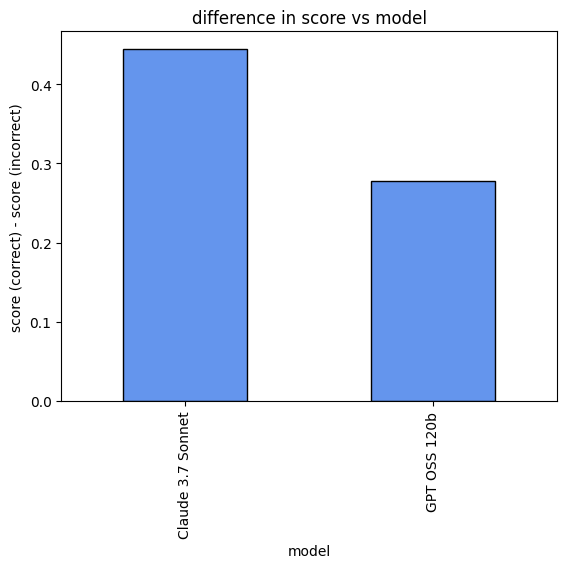

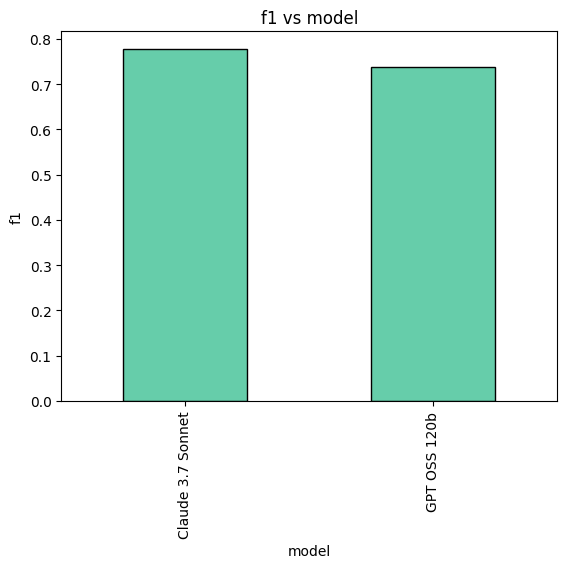

In [15]:
plot_df = results_df.set_index("model_name")

if len(plot_df) > 0:
    display(plot_df)
    plot_df["score_diff"].plot(kind="bar", xlabel="model",  ylabel="score (correct) - score (incorrect)", title=f"difference in score vs model", color="cornflowerblue", edgecolor="black")
    plt.show()
    plot_df["f1"].plot(kind="bar", xlabel="model", ylabel="f1", title=f"f1 vs model", color="mediumaquamarine", edgecolor="black")
    plt.show()